# Feature and Output Distribution Plots

Generate distribution plots for FALCON input features and measured output columns.

- Select the `falcon-env` kernel.
- Set the run and dataset names in the configuration cell.
- Figures are saved to `../output/{RUN_NAME}/distribution_plots/`.


In [1]:
### Required Run Parameters ###

RUN_NAME = "PLGA_PEC_80"  # Name of output folder from which to load the run
DATASET_NAME = "PLGA_PEC_80"  # Name of CSV file in ../datasets, without .csv

input_param_names = [
    "Solvent_Polarity",
    "DS_MW",
    "DS Concentration",
    "Polymer_MW",
    "Polymer concentration",
]

# Measured response/output columns to plot. Set to None to infer numeric outputs.
output_names = [
    "Encapsulation efficiency (%)",
    "Size",
    "Zeta Potential",
    "Release D5",
    "Release D10",
    "Release D30",
]

# Set to a column name, such as "Solvent" or "Helper_lipid", to color distributions by group.
hue_col = "Solvent"

# Retained for compatibility with older versions of this notebook; count plots use observed categories.
log_scale_cols = []


## Setup

In [2]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
sns.set_style("white")


In [3]:
dataset_path = Path("../datasets") / f"{DATASET_NAME}.csv"
run_output_path = Path("../output") / RUN_NAME
figure_output_path = run_output_path / "distribution_plots"
figure_output_path.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(dataset_path)

# Drop fully empty columns, including unnamed trailing CSV columns.
df = df_raw.dropna(axis=1, how="all").copy()
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

print(f"Loaded {dataset_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")


Loaded ../datasets/PLGA_PEC_80.csv
Rows: 80
Columns: 18


## Helpers

In [4]:
def infer_output_columns(df, input_cols):
    metadata_cols = {
        "Formula_label", "Formula_Label", "Formula label",
        "Iter", "Opt_Method", "Ionizable_lipid", "Helper_lipid", "Solvent",
        "Experimenta #", "Experimental #", "Experiment #",
    }
    exclude = set(input_cols) | metadata_cols
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [col for col in numeric_cols if col not in exclude]


def existing_columns(df, columns, label):
    present = [col for col in columns if col in df.columns]
    missing = [col for col in columns if col not in df.columns]
    if missing:
        print(f"Missing {label} columns skipped: {missing}")
    return present


def format_observed_value(value):
    value = float(value)
    if value.is_integer():
        return f"{value:.0f}"
    return f"{value:g}"


def plot_distribution_grid(
    df,
    columns,
    title,
    output_stem,
    hue=None,
    log_scale_cols=None,
    bins=14,
    ncols=3,
    plot_kind="hist",
):
    columns = existing_columns(df, columns, title.lower())
    if not columns:
        raise ValueError(f"No columns available for {title}.")

    log_scale_cols = set(log_scale_cols or [])
    hue = hue if hue in df.columns else None

    nrows = math.ceil(len(columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), dpi=200)
    axes = np.asarray(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        plot_data = df[[col] + ([hue] if hue else [])].dropna()
        numeric_values = pd.to_numeric(plot_data[col], errors="coerce")
        plot_data = plot_data.loc[numeric_values.notna()].copy()
        plot_data[col] = numeric_values[numeric_values.notna()]

        if hue:
            n_groups = plot_data[hue].nunique(dropna=True)
            palette = sns.color_palette("Set2", n_colors=max(n_groups, 1))
        else:
            palette = None

        if plot_kind == "count":
            observed_values = sorted(plot_data[col].dropna().unique())
            sns.countplot(
                data=plot_data,
                x=col,
                hue=hue,
                order=observed_values,
                edgecolor="black",
                linewidth=1,
                palette=palette,
                ax=ax,
            )
            labels = [format_observed_value(value) for value in observed_values]
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right")

        elif plot_kind == "hist":
            sns.histplot(
                data=plot_data,
                x=col,
                hue=hue,
                bins=bins,
                kde=False,
                element="bars",
                stat="count",
                common_norm=False,
                edgecolor="black",
                linewidth=1,
                palette=palette,
                ax=ax,
            )
            if col in log_scale_cols and (plot_data[col] > 0).all():
                ax.set_xscale("log")

        else:
            raise ValueError("plot_kind must be 'count' or 'hist'.")

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

        ax.set_title(col, fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()

    svg_path = figure_output_path / f"{output_stem}.svg"
    png_path = figure_output_path / f"{output_stem}.png"
    fig.savefig(svg_path, dpi=600, format="svg", transparent=True, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, transparent=True, bbox_inches="tight")
    print(f"Saved {svg_path}")
    print(f"Saved {png_path}")
    return fig, axes


## Column Summary

In [5]:
feature_cols = existing_columns(df, input_param_names, "feature")
output_cols = infer_output_columns(df, feature_cols) if output_names is None else existing_columns(df, output_names, "output")

print("Feature columns:")
print(feature_cols)
print()
print("Output columns:")
print(output_cols)

summary_cols = feature_cols + output_cols
summary = df[summary_cols].describe().T
summary


Feature columns:
['Solvent_Polarity', 'DS_MW', 'DS Concentration', 'Polymer_MW', 'Polymer concentration']

Output columns:
['Encapsulation efficiency (%)', 'Size', 'Zeta Potential', 'Release D5', 'Release D10', 'Release D30']


,count,mean,std,min,25%,50%,75%,max
Solvent_Polarity,80.0,4.300000,0.805047,3.500000,3.500000,4.300000,5.100000,5.100000
DS_MW,80.0,244243.750000,206223.609647,6500.000000,100000.000000,100000.000000,500000.000000,500000.000000
DS Concentration,80.0,0.634375,0.240134,0.250000,0.500000,0.750000,0.750000,1.000000
Polymer_MW,80.0,40187.500000,21720.953979,5000.000000,20000.000000,45000.000000,55000.000000,75000.000000
Polymer concentration,80.0,2.595312,1.606608,0.250000,1.250000,2.500000,5.000000,5.000000
Encapsulation efficiency (%),77.0,89.672010,12.967090,45.000000,88.000000,94.810255,98.597475,100.000000
Size,40.0,95.782772,21.134248,59.373330,82.879168,88.260000,109.708325,152.400000
Zeta Potential,40.0,-34.022417,8.672568,-47.500000,-40.233333,-34.866667,-29.550000,-6.896667
Release D5,79.0,5.082483,2.801114,0.000000,3.136435,4.865230,6.735271,15.884007
Release D10,79.0,18.766372,21.935046,3.447394,6.418570,8.643862,20.685038,85.911369


## Feature Distributions

Saved ../output/PLGA_PEC_80/distribution_plots/feature_distributions.svg
Saved ../output/PLGA_PEC_80/distribution_plots/feature_distributions.png


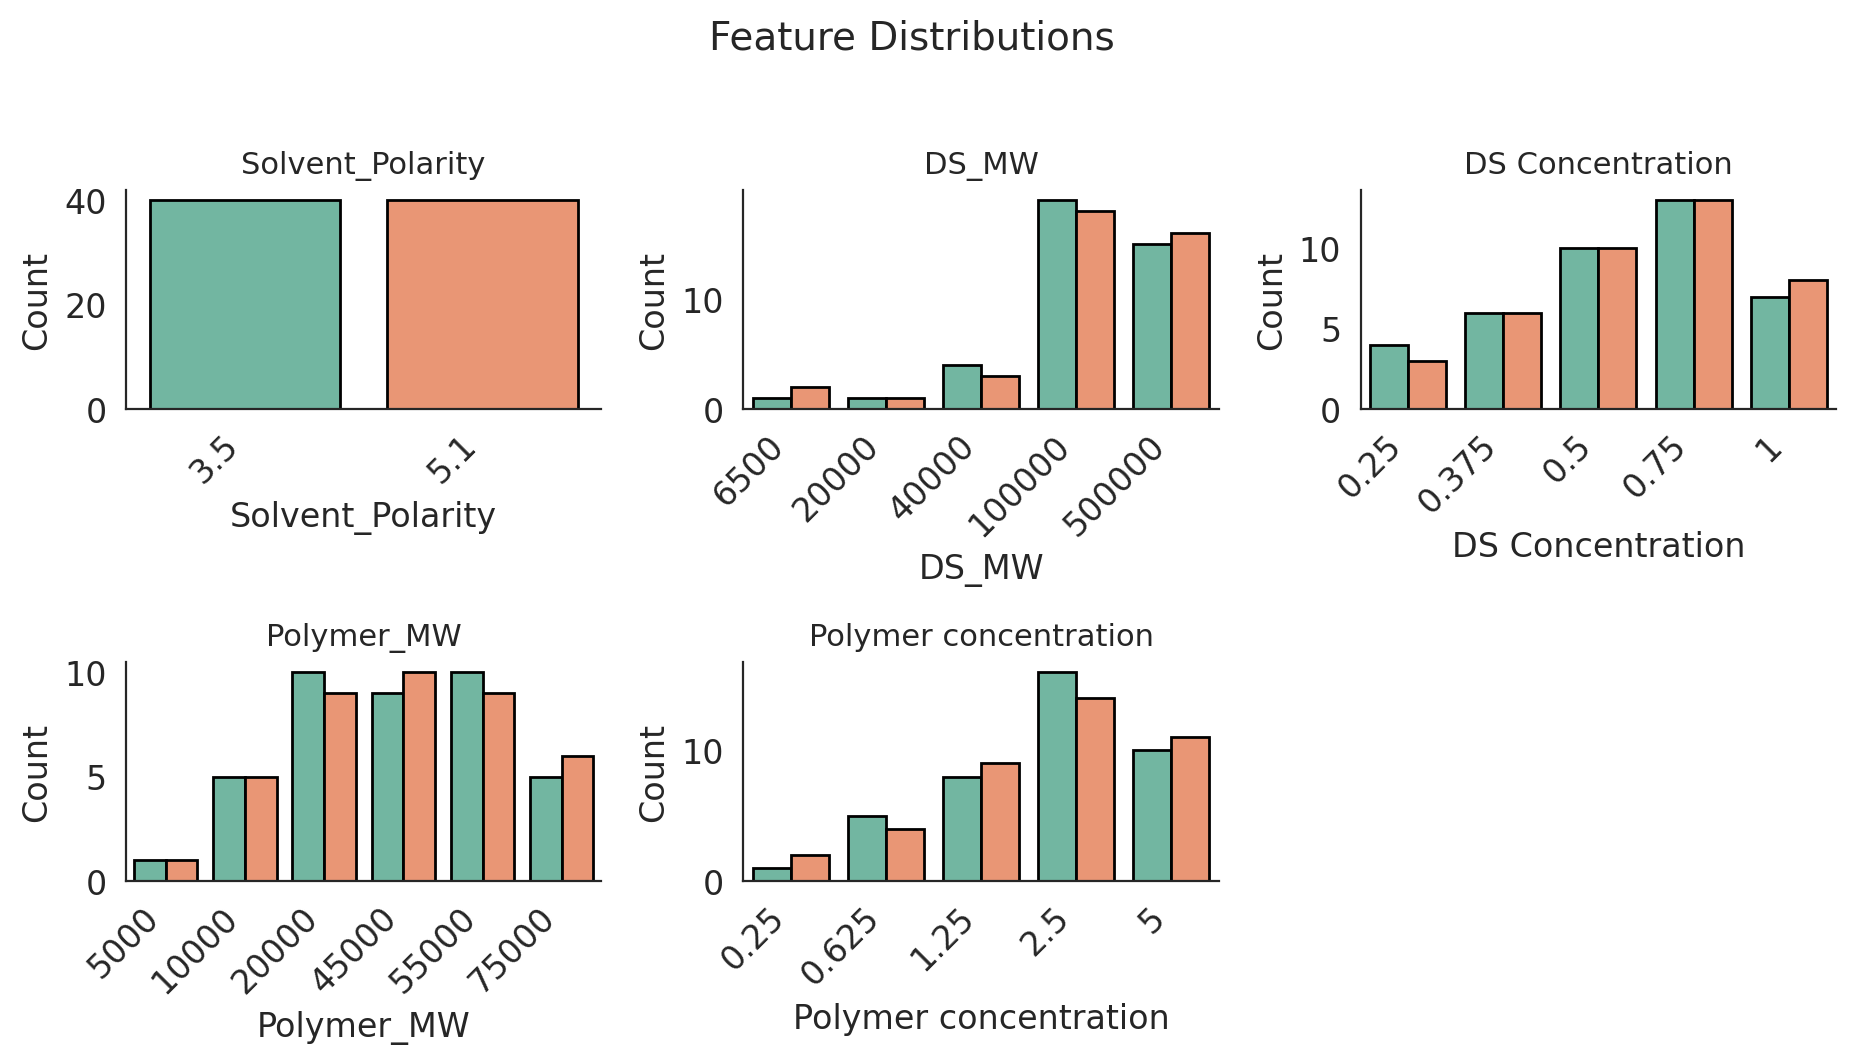

In [6]:
feature_fig, feature_axes = plot_distribution_grid(
    df,
    feature_cols,
    title="Feature Distributions",
    output_stem="feature_distributions",
    hue=hue_col,
    log_scale_cols=log_scale_cols,
    plot_kind="count",
)


## Output Distributions

Saved ../output/PLGA_PEC_80/distribution_plots/output_distributions.svg
Saved ../output/PLGA_PEC_80/distribution_plots/output_distributions.png


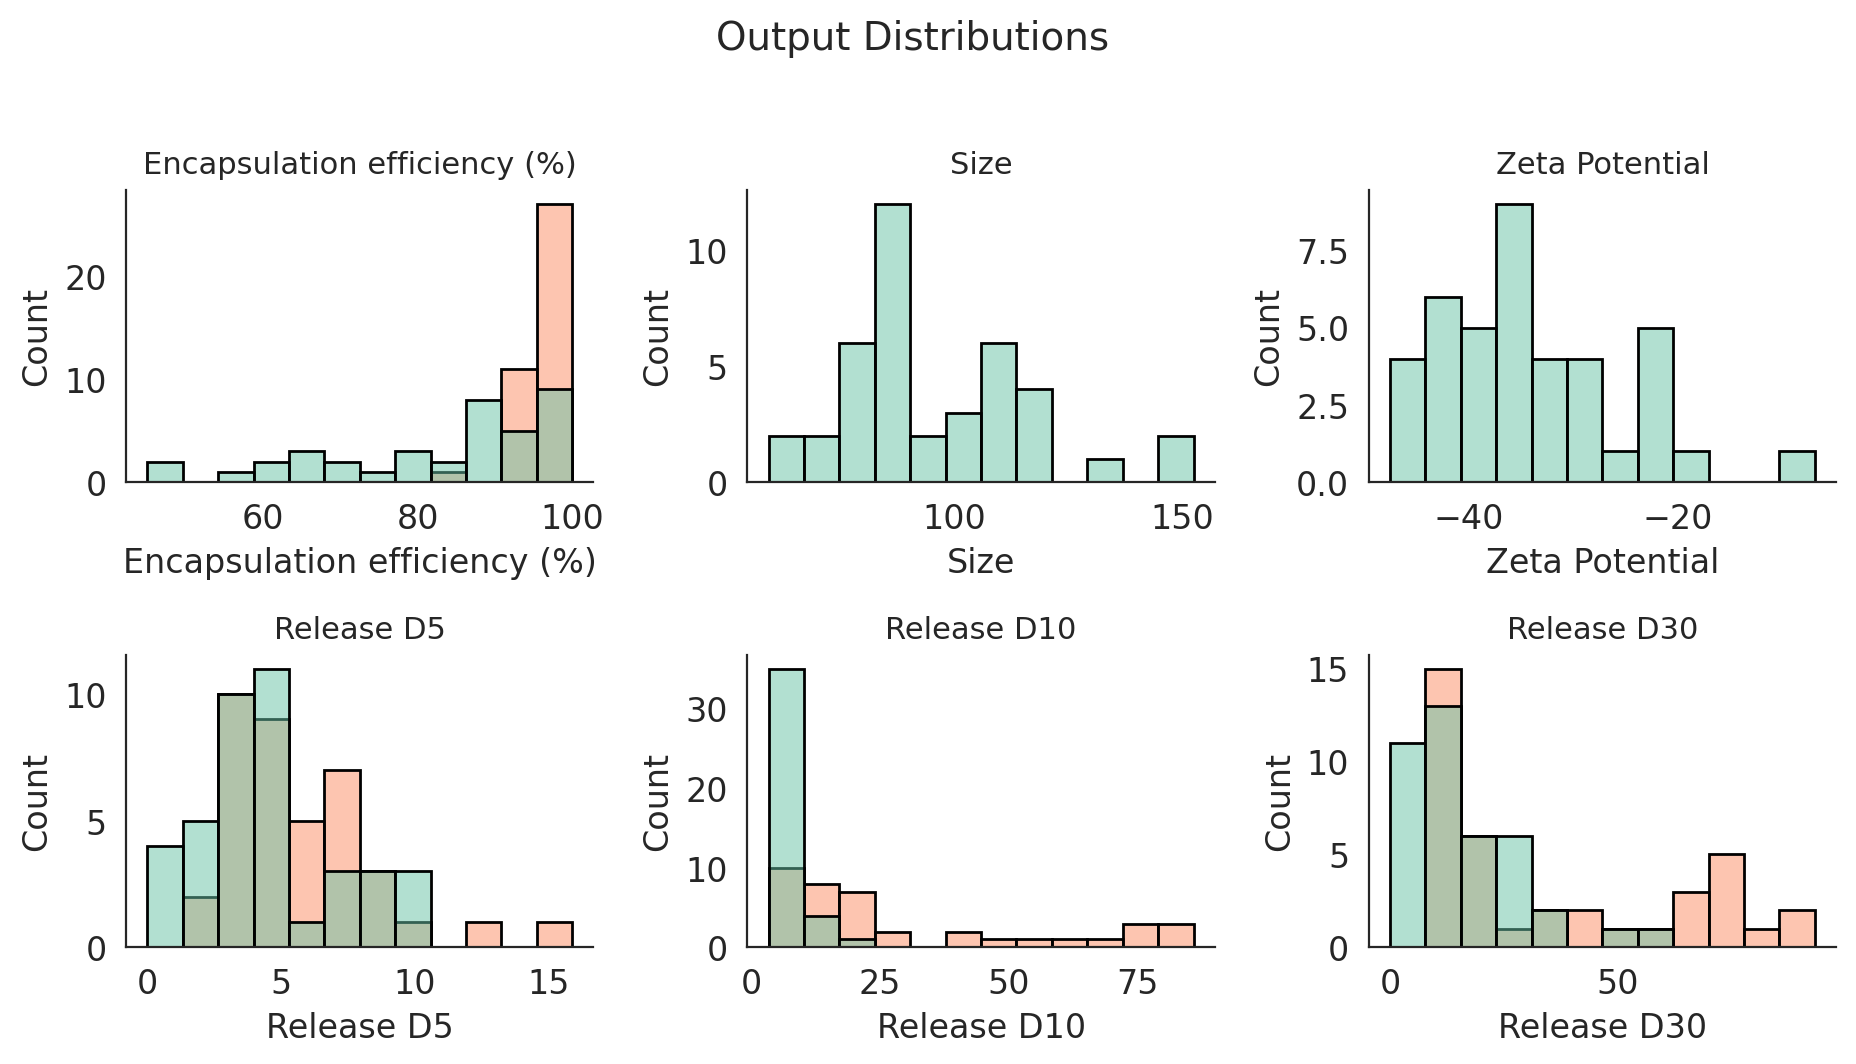

In [7]:
output_fig, output_axes = plot_distribution_grid(
    df,
    output_cols,
    title="Output Distributions",
    output_stem="output_distributions",
    hue=hue_col,
    log_scale_cols=[],
    bins=12,
    plot_kind="hist",
)
